# 01. Alur pelatihan klasifikasi sentimen

Membangun model, menghitung loss, memperbarui bobot, memilih checkpoint melalui validasi, dan menguji pemuatan ulang. Proyek berkelanjutan kursus ini adalah klasifikasi sentimen ulasan.

**Prasyarat:** modul 00.

**Pola belajar:** baca penjelasan, prediksi bentuk keluaran, jalankan kode, lalu ubah satu hal.

Contoh ulasan dalam paket ini merupakan data sintetis untuk mempelajari mekanisme. Metriknya tidak mewakili kinerja pada ulasan nyata.

## Penyiapan

Instal dependensi melalui petunjuk README sebelum menjalankan seluruh sel. Setiap notebook dapat dimulai dengan kernel baru. GPU bersifat opsional. Semua operasi tensor yang berinteraksi harus berada pada perangkat yang sesuai.

In [1]:
from pathlib import Path
import sys
# Lokal: buka dari root repo, folder nlp, atau nlp/notebooks.
# Colab: ambil paket kursus jika belum tersedia.
candidates = [Path.cwd(), *Path.cwd().parents]
ROOT = next((p for base in candidates for p in (base, base / "nlp")
             if (p / "nlp_course").is_dir()), None)
if ROOT is None and "google.colab" in sys.modules:
    import subprocess
    target = Path("/content/pytorch-deep-learning-nlp")
    if not target.exists():
        subprocess.run(["git", "clone", "--depth", "1", "--filter=blob:none",
                        "--sparse", "--branch", "nlp-learning-path",
                        "https://github.com/FeliksMakarios/pytorch-deep-learning.git",
                        str(target)], check=True)
        subprocess.run(["git", "sparse-checkout", "set", "nlp"], cwd=target, check=True)
    ROOT = target / "nlp"
if ROOT is None or not (ROOT / "nlp_course").is_dir():
    raise RuntimeError("Folder nlp_course tidak ditemukan. Ikuti petunjuk README nlp.")
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
import torch
from torch import nn
from nlp_course.data import tokenize, build_vocab, encode, read_rows, loaders, collate_batch
from nlp_course.models import MeanClassifier, RecurrentClassifier, TinyTransformer
from nlp_course.engine import seed_all, fit, run_epoch, metrics, save_mean, load_mean, predict
seed_all(42)
torch.set_num_threads(1)
device = "cuda" if torch.cuda.is_available() else "cpu"
ARTIFACTS = ROOT / "artifacts"
ARTIFACTS.mkdir(exist_ok=True)
print("PyTorch:", torch.__version__, "Perangkat:", device)

PyTorch: 2.14.0+cu130 Perangkat: cpu


## 1. Pisahkan data sebelum mempelajari kosakata

Data latih memperbarui bobot. Data validasi memilih pengaturan dan checkpoint. Data uji digunakan setelah keputusan tersebut selesai. Dataset disusun dengan kelompok pola kalimat yang berbeda antarsplit. Pengelompokan ini mengurangi pengulangan pola persis, meskipun bahasanya tetap sederhana.

In [2]:
from collections import Counter
rows = read_rows()
print(Counter((r["split"], r["label"]) for r in rows))
train_rows = [r for r in rows if r["split"] == "train"]
val_rows = [r for r in rows if r["split"] == "val"]
test_rows = [r for r in rows if r["split"] == "test"]
vocab = build_vocab(r["text"] for r in train_rows)
print("Ukuran kosakata:", len(vocab))
print("Kata baru:", encode("kosakatabaru", vocab))

Counter({('train', 0): 144, ('train', 1): 144, ('val', 0): 48, ('val', 1): 48, ('test', 0): 48, ('test', 1): 48})
Ukuran kosakata: 27
Kata baru: [1]


## 2. Representasi kalimat sederhana

Untuk memusatkan perhatian pada siklus optimasi, kita mulai dengan bag-of-words berupa frekuensi token. Model ini mengabaikan urutan. Semua fitur harus memakai kosakata latih yang sama.

In [3]:
def bow(part):
    x = torch.zeros(len(part), len(vocab))
    y = torch.tensor([r["label"] for r in part])
    for i, row in enumerate(part):
        for token in encode(row["text"], vocab):
            x[i, token] += 1
    return x, y
x_train, y_train = bow(train_rows)
x_val, y_val = bow(val_rows)
x_test, y_test = bow(test_rows)
print(x_train.shape, y_train.shape)

torch.Size([288, 27]) torch.Size([288])


## 3. Definisi model dan pemeriksaan awal

Lapisan linear menghubungkan fitur token dengan dua skor kelas. Target berupa bilangan bulat 0 atau 1. `CrossEntropyLoss` menggabungkan log-softmax dengan negative log-likelihood, jadi jangan menambahkan softmax sebelum loss.

In [4]:
model = nn.Linear(len(vocab), 2)
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.03)
with torch.inference_mode():
    print("Loss awal:", criterion(model(x_train), y_train).item())
print("Jumlah parameter:", sum(p.numel() for p in model.parameters()))

Loss awal: 0.7087477445602417
Jumlah parameter: 56


## 4. Siklus pelatihan yang terlihat lengkap

Urutannya adalah forward, loss, kosongkan gradien, backward, lalu langkah optimizer. Beralih ke `eval()` saat validasi. `eval()` mengubah perilaku lapisan tertentu, sedangkan `inference_mode()` menonaktifkan pencatatan gradien. Keduanya memiliki fungsi berbeda.

In [5]:
import copy
history = []
best_loss = float("inf")
best_state = None
for epoch in range(80):
    model.train()
    logits = model(x_train)
    loss = criterion(logits, y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    model.eval()
    with torch.inference_mode():
        val_loss = criterion(model(x_val), y_val).item()
    history.append((loss.item(), val_loss))
    if val_loss < best_loss:
        best_loss = val_loss
        best_state = copy.deepcopy(model.state_dict())
model.load_state_dict(best_state)
print("Loss latih awal/akhir:", history[0][0], history[-1][0])
print("Loss validasi terbaik:", best_loss)

Loss latih awal/akhir: 0.7087477445602417 0.38871052861213684
Loss validasi terbaik: 0.3938886225223541


## 5. Membaca kurva pembelajaran

Loss latih yang turun belum menjamin generalisasi. Jika loss validasi meningkat saat loss latih turun, model dapat mulai menyesuaikan diri secara berlebihan terhadap data latih. Jangan memilih jumlah epoch dengan melihat data uji.

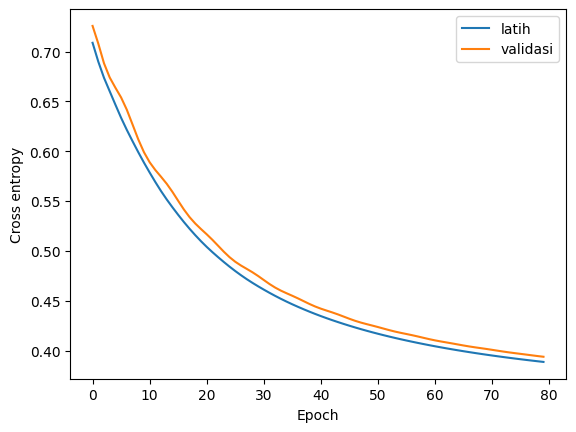

In [6]:
import matplotlib.pyplot as plt
plt.plot([x[0] for x in history],label="latih")
plt.plot([x[1] for x in history],label="validasi")
plt.xlabel("Epoch")
plt.ylabel("Cross entropy")
plt.legend()
plt.show()

## 6. Evaluasi uji setelah model dipilih

Laporkan metrik beserta konteks dataset. Ketepatan pada kalimat sintetis belum menunjukkan kemampuan memahami ironi, negasi kompleks, atau bahasa percakapan.

In [7]:
model.eval()
with torch.inference_mode():
    predictions = model(x_test).argmax(1)
print(metrics(y_test.tolist(), predictions.tolist()))
for row, pred in list(zip(test_rows, predictions.tolist()))[:6]:
    print(row["text"], "label:", row["label"], "prediksi:", pred)

{'accuracy': 0.75, 'macro_f1': 0.7333333492279053, 'confusion': [[48, 0], [24, 24]]}
bagi saya kualitas buku buruk label: 0 prediksi: 0
bagi saya kualitas buku mengecewakan label: 0 prediksi: 0
bagi saya kualitas buku tidak baik label: 0 prediksi: 0
bagi saya kualitas buku kurang memuaskan label: 0 prediksi: 0
bagi saya kualitas buku baik label: 1 prediksi: 0
bagi saya kualitas buku memuaskan label: 1 prediksi: 1


## 7. Simpan dan muat ulang

Simpan kosakata bersama parameter. Bobot saja tidak cukup karena urutan indeks token menentukan maknanya bagi model. Pemuatan diuji dengan membandingkan skor sebelum dan sesudah penyimpanan.

In [8]:
path = ARTIFACTS / "bow.pt"
torch.save({"state_dict": model.state_dict(), "vocab": vocab}, path)
checkpoint = torch.load(path, weights_only=True)
restored = nn.Linear(len(checkpoint["vocab"]), 2)
restored.load_state_dict(checkpoint["state_dict"])
restored.eval()
with torch.inference_mode():
    assert torch.allclose(model(x_test), restored(x_test))
print("Skor hasil pemuatan identik.")

Skor hasil pemuatan identik.


## Latihan mandiri

1. Apa akibat membuat kosakata dari seluruh data?
2. Mengapa best_state perlu salinan?
3. Apa akibat melewatkan zero_grad?
4. Ubah laju belajar dan bandingkan kurva validasi.

## Pembahasan latihan

1. Informasi distribusi kata dari validasi dan uji masuk ke tahap pembentukan fitur.
2. Referensi bobot yang terus diperbarui tidak menyimpan keadaan epoch terbaik.
3. Gradien antarlangkah terakumulasi dan mengubah aturan pembaruan yang dimaksud.
4. Tidak ada nilai terbaik universal. Catat perubahan loss, kestabilan, dan seed.

## Penghubung ke materi berikutnya

Modul 02 mengganti fitur frekuensi dengan embedding yang dipelajari serta memperluas evaluasi kesalahan.

### Rujukan
- [Dokumentasi PyTorch](https://docs.pytorch.org/docs/stable/index.html)
- [Sumber Embedding](https://github.com/pytorch/pytorch/blob/main/torch/nn/modules/sparse.py)
- [Sumber Transformer](https://github.com/pytorch/pytorch/blob/main/torch/nn/modules/transformer.py)
- [Kursus sumber dan struktur awal](https://github.com/mrdbourke/pytorch-deep-learning)

Materi ini ditulis sebagai jalur NLP mandiri. Penjelasan dan contoh NLP bukan terjemahan resmi kursus sumber.